# Gradient Boosting — Churn Prediction Model

Training a Gradient Boosting classifier (sklearn) on the
feature-engineered churn dataset. Includes hyperparameter
tuning and full evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
from imblearn.over_sampling import SMOTE

## 1 · Data Loading & Prep

Dropping features that leak the churn outcome:

| Feature | Why it leaks |
|:--------|:-------------|
| `Total_Net_Paid` | Churned = 0 (didn't pay — set after churn) |
| `price_change_pct/abs` | Derived from Total_Net_Paid |
| `net_paid_vs_last` | Ratio involving current payment (0 for churned) |
| `Payment_Method` | Set to UNKNOWN after churn |
| `Payment_Timeframe` | All churned = 0 |
| `Days_To_Close_Post_Renewal` | Uses close date (post-outcome) |
| `Total_Renewal_Score_New` | Composite encodes outcome |

In [2]:
project_root = Path.cwd()
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent

data_path = project_root / "data" / "processed" / "model_ready_dataset.csv"
if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at {data_path}. "
        "Make sure you run the notebook from the repo root or run the data prep pipeline first."
    )

df = pd.read_csv(data_path)
print(f"Loaded shape: {df.shape}")

df = df[df["Prospect_Outcome"].isin(["Won", "Churned"])].copy()
df["target"] = (df["Prospect_Outcome"] == "Churned").astype(int)
df.drop(columns=["Prospect_Outcome"], inplace=True)

# ---- DROP LEAKY FEATURES ------------------------------------------------
leaky_cols = [
    "Total_Net_Paid", "price_change_pct", "price_change_abs",
    "net_paid_vs_last", "Payment_Method", "Payment_Timeframe",
    "Days_To_Close_Post_Renewal", "Total_Renewal_Score_New",
    "Renewal_Year",
]
cols_before = set(df.columns)
df.drop(columns=leaky_cols, inplace=True, errors="ignore")
actually_dropped = cols_before - set(df.columns)
print(f"Dropped {len(actually_dropped)} leaky/non-predictive features: {sorted(actually_dropped)}")

# --- SPLIT FIRST, THEN ENCODE --------------------------------------------
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# encode categoricals — fit on train only
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
if cat_cols:
    ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_train.loc[:, cat_cols] = ord_enc.fit_transform(X_train[cat_cols]).astype(float)
    X_test.loc[:, cat_cols] = ord_enc.transform(X_test[cat_cols]).astype(float)

# Ensure all columns are numeric
X_train = X_train.apply(pd.to_numeric, errors="coerce").fillna(0)
X_test = X_test.apply(pd.to_numeric, errors="coerce").fillna(0)

# --- SMOTE: oversample the minority class on TRAINING data only ----
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
print(f"After SMOTE -> Train: {X_train.shape[0]}  (Churn: {y_train.mean():.2%})")

print(f"\nFeatures: {X_train.shape[1]}")
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Churn rate — Train: {y_train.mean():.2%}, Test: {y_test.mean():.2%}")

Loaded shape: (122082, 57)
Dropped 9 leaky/non-predictive features: ['Days_To_Close_Post_Renewal', 'Payment_Method', 'Payment_Timeframe', 'Renewal_Year', 'Total_Net_Paid', 'Total_Renewal_Score_New', 'net_paid_vs_last', 'price_change_abs', 'price_change_pct']
After SMOTE -> Train: 161962  (Churn: 50.00%)

Features: 47
Train: 161962, Test: 22779
Churn rate — Train: 50.00%, Test: 11.12%


## 2 · Baseline Gradient Boosting

In [3]:
gb_base = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    subsample=0.8,
)
gb_base.fit(X_train, y_train)

y_pred_base = gb_base.predict(X_test)
y_prob_base = gb_base.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "Precision": precision_score(y_test, y_pred_base),
    "Recall": recall_score(y_test, y_pred_base),
    "F1 Score": f1_score(y_test, y_pred_base),
    "ROC AUC": roc_auc_score(y_test, y_prob_base),
}

print("=" * 60)
print("BASELINE GRADIENT BOOSTING RESULTS")
print("=" * 60)
for k, v in baseline_metrics.items():
    print(f"{k:<10}: {v:.4f}")
print()
print(classification_report(y_test, y_pred_base, target_names=["Won", "Churned"]))

BASELINE GRADIENT BOOSTING RESULTS
Accuracy  : 0.9460
Precision : 0.7199
Recall    : 0.8429
F1 Score  : 0.7766
ROC AUC   : 0.9736

              precision    recall  f1-score   support

         Won       0.98      0.96      0.97     20245
     Churned       0.72      0.84      0.78      2534

    accuracy                           0.95     22779
   macro avg       0.85      0.90      0.87     22779
weighted avg       0.95      0.95      0.95     22779



## 3 · Hyperparameter Tuning

Manual config search with 3-fold CV to keep runtime reasonable.
sklearn's GradientBoosting can't parallelise tree building
so we keep the grid compact.

In [4]:
configs = [
    {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.1, "subsample": 0.8},
    {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.1, "subsample": 0.8},
    {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.8},
    {"n_estimators": 300, "max_depth": 3, "learning_rate": 0.05, "subsample": 0.9},
    {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.1, "subsample": 1.0},
]

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
best_f1 = 0
best_config = None

for i, cfg in enumerate(configs):
    model = GradientBoostingClassifier(**cfg, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv_strat, scoring="f1")
    mean_f1 = scores.mean()
    print(f"Config {i+1}: F1={mean_f1:.4f} (+/- {scores.std():.4f})  {cfg}")
    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_config = cfg

print(f"\nBest config: {best_config}")
print(f"Best CV F1:  {best_f1:.4f}")

Config 1: F1=0.9495 (+/- 0.0008)  {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8}
Config 2: F1=0.9638 (+/- 0.0002)  {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8}
Config 3: F1=0.9654 (+/- 0.0006)  {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8}
Config 4: F1=0.9585 (+/- 0.0001)  {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.9}
Config 5: F1=0.9719 (+/- 0.0004)  {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 1.0}

Best config: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 1.0}
Best CV F1:  0.9719


## 4 · Best Model Evaluation

In [5]:
# guard: fall back to baseline params if tuning cell wasn't run
if best_config is None or not isinstance(best_config, dict):
    warnings.warn("best_config not found — using baseline defaults")
    best_config = {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.1, "subsample": 0.8}

best_gb = GradientBoostingClassifier(**best_config, random_state=42)
best_gb.fit(X_train, y_train)

y_pred = best_gb.predict(X_test)
y_prob = best_gb.predict_proba(X_test)[:, 1]

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC AUC": roc_auc_score(y_test, y_prob),
}

print("=" * 60)
print("TUNED GRADIENT BOOSTING RESULTS")
print("=" * 60)
for k, v in tuned_metrics.items():
    print(f"{k:<10}: {v:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Won", "Churned"]))

TUNED GRADIENT BOOSTING RESULTS
Accuracy  : 0.9540
Precision : 0.7821
Recall    : 0.8129
F1 Score  : 0.7972
ROC AUC   : 0.9780

              precision    recall  f1-score   support

         Won       0.98      0.97      0.97     20245
     Churned       0.78      0.81      0.80      2534

    accuracy                           0.95     22779
   macro avg       0.88      0.89      0.89     22779
weighted avg       0.95      0.95      0.95     22779



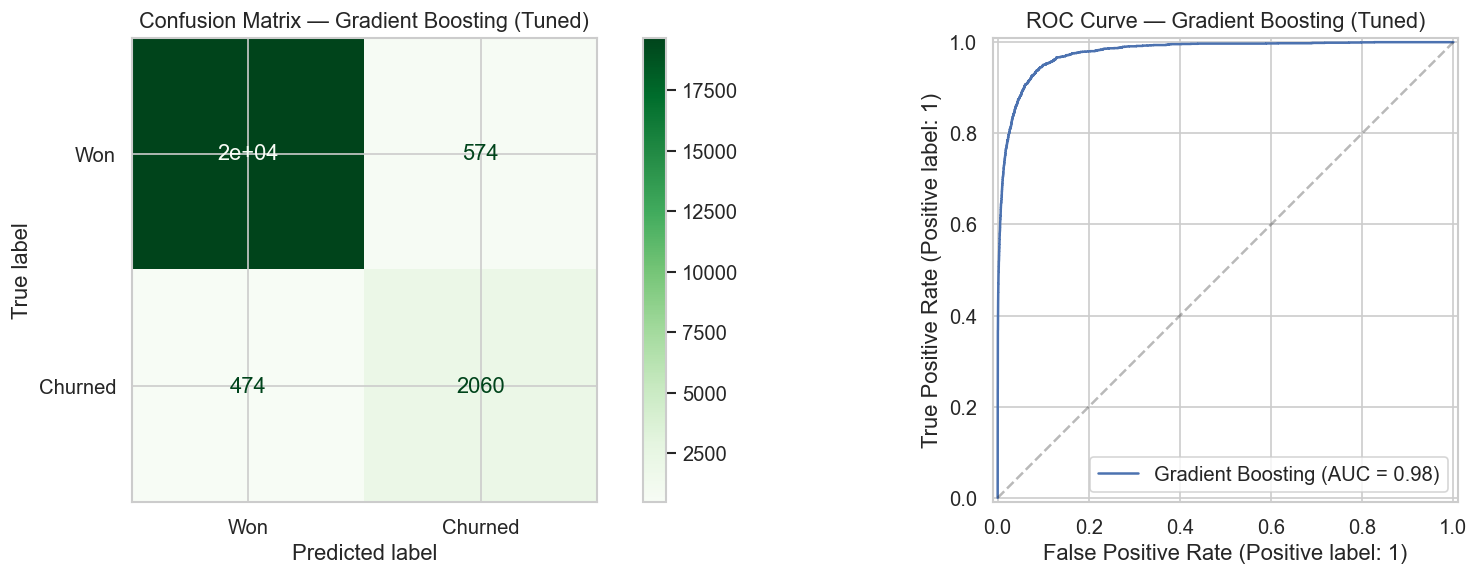

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Won", "Churned"], ax=axes[0],
    cmap="Greens"
)
axes[0].set_title("Confusion Matrix — Gradient Boosting (Tuned)", fontsize=13)

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name="Gradient Boosting")
axes[1].set_title("ROC Curve — Gradient Boosting (Tuned)", fontsize=13)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)

plt.tight_layout()
plt.show()

## 5 · Feature Importance

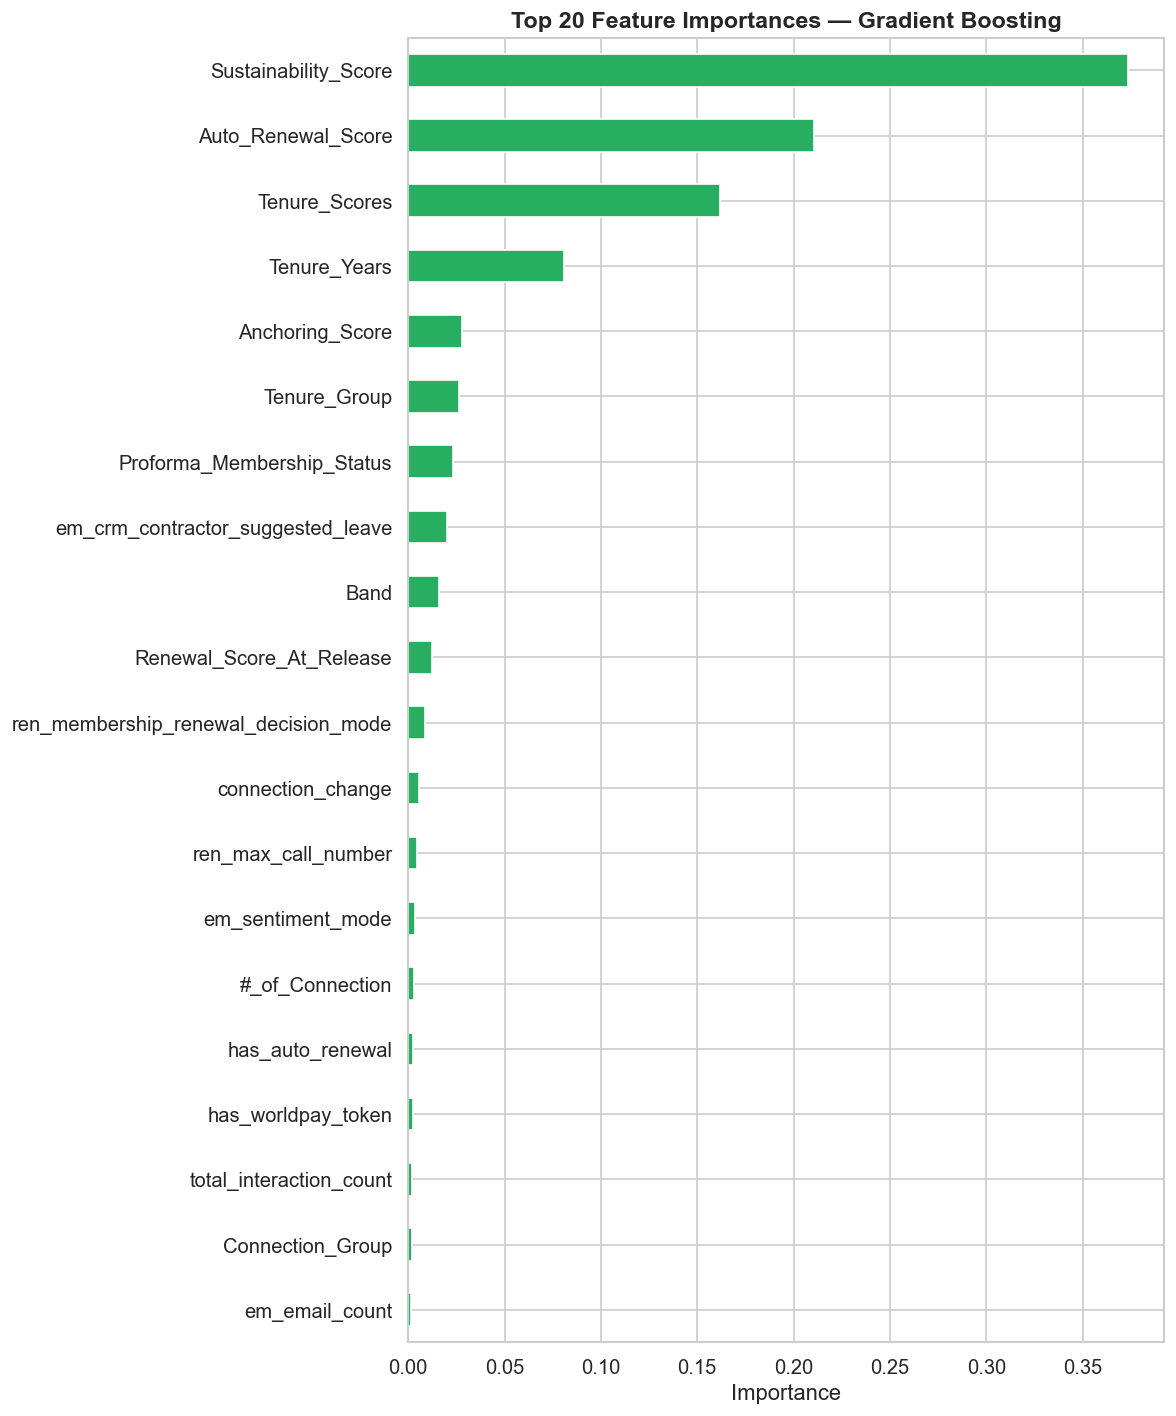

In [7]:
importances = best_gb.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
feat_imp.tail(20).plot.barh(ax=ax, color="#27ae60", edgecolor="white")
ax.set_title("Top 20 Feature Importances — Gradient Boosting", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 6 · Training Loss Curve

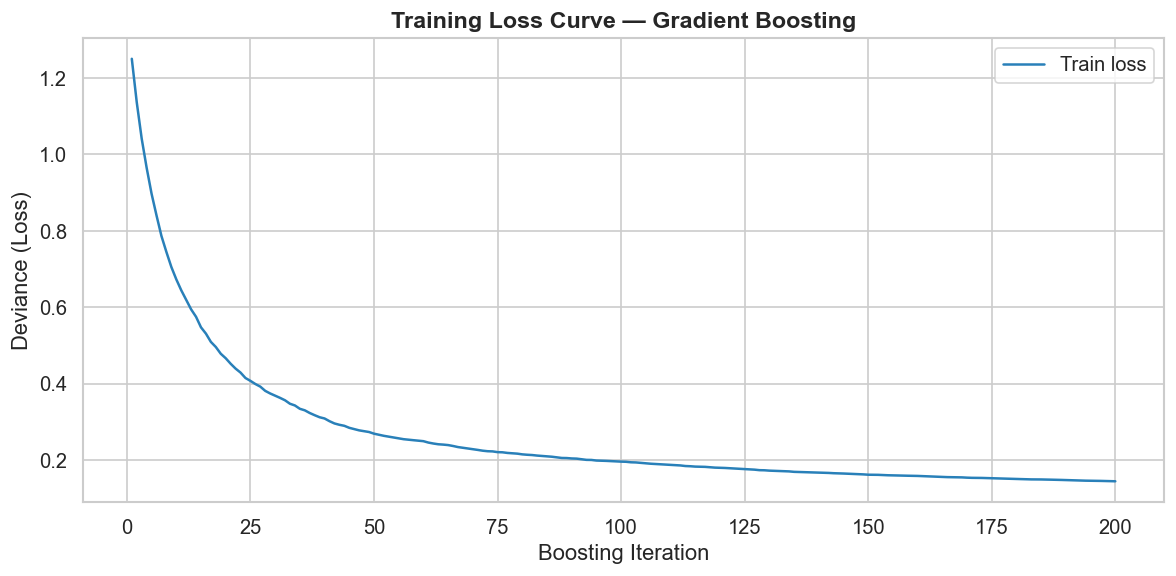

In [8]:
train_loss = best_gb.train_score_

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(train_loss) + 1), train_loss, label="Train loss", color="#2980b9")
ax.set_xlabel("Boosting Iteration")
ax.set_ylabel("Deviance (Loss)")
ax.set_title("Training Loss Curve — Gradient Boosting", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

In [9]:
summary = pd.DataFrame({"Baseline": baseline_metrics, "Tuned": tuned_metrics})
summary = summary.round(4)
try:
    print(summary.to_markdown())
except ImportError:
    print(summary.to_string())

|           |   Baseline |   Tuned |
|:----------|-----------:|--------:|
| Accuracy  |     0.946  |  0.954  |
| Precision |     0.7199 |  0.7821 |
| Recall    |     0.8429 |  0.8129 |
| F1 Score  |     0.7766 |  0.7972 |
| ROC AUC   |     0.9736 |  0.978  |
